# Assignment 4 DS351

# Hasnain Ali Ahmed / 2023234

## 1 & 2. Dataset Selections
* **Tree Dataset:** The Standard Model of Particle Physics Taxonomy.
* **Graph Dataset:** 4x4 Torus Interconnect Network.

## 3. Dataset Descriptions

### Tree Dataset (Standard Model Taxonomy)
* **Source:** A custom hierarchical dataset curated from the theoretical physics classification of elementary particles.
* **Nodes Represent:** Categories of particles (e.g., Fermions, Bosons) and specific fundamental particles (e.g., Up Quark, Electron, Higgs Boson).
* **Edges Represent:** A taxonomic "is a sub-category of" or "contains" relationship, branching from a central root down to specific particle classifications.

### Graph Dataset (Torus Interconnect Mesh)
* **Source:** A synthetically generated dataset modeling a standard parallel computing architecture, commonly used in supercomputer network topologies. Generated using `NetworkX`.
* **Nodes Represent:** Compute nodes or individual processors within a distributed system.
* **Edges Represent:** Direct, bi-directional physical communication links between adjacent processors in the mesh.

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# 1. Initialize the Tree Dataset (Physics Taxonomy)
# ==========================================
tree_data = nx.DiGraph()

# Define the hierarchical relationships
tree_edges = [
    ("Elementary Particles", "Fermions"),
    ("Elementary Particles", "Bosons"),
    ("Fermions", "Quarks"),
    ("Fermions", "Leptons"),
    ("Bosons", "Gauge Bosons"),
    ("Bosons", "Scalar Bosons"),
    ("Quarks", "Up-type"),
    ("Quarks", "Down-type"),
    ("Leptons", "Electron-like"),
    ("Leptons", "Neutrinos"),
    ("Gauge Bosons", "Photon"),
    ("Gauge Bosons", "Gluon"),
    ("Gauge Bosons", "W/Z Bosons"),
    ("Scalar Bosons", "Higgs Boson")
]
tree_data.add_edges_from(tree_edges);

# Assign layer depths for hierarchical layout plotting later
layers = {
    "Elementary Particles": 0,
    "Fermions": 1, "Bosons": 1,
    "Quarks": 2, "Leptons": 2, "Gauge Bosons": 2, "Scalar Bosons": 2,
    "Up-type": 3, "Down-type": 3, "Electron-like": 3, "Neutrinos": 3,
    "Photon": 3, "Gluon": 3, "W/Z Bosons": 3, "Higgs Boson": 3
}
nx.set_node_attributes(tree_data, layers, 'layer')

# ==========================================
# 2. Initialize the Graph Dataset (Torus Network)
# ==========================================
# Generates a 4x4 grid wrapped around at the edges (a torus mesh)
graph_data = nx.grid_2d_graph(4, 4, periodic=True)

# Rename nodes to simple integers for cleaner visualization
mapping = {node: i for i, node in enumerate(graph_data.nodes())}
graph_data = nx.relabel_nodes(graph_data, mapping)

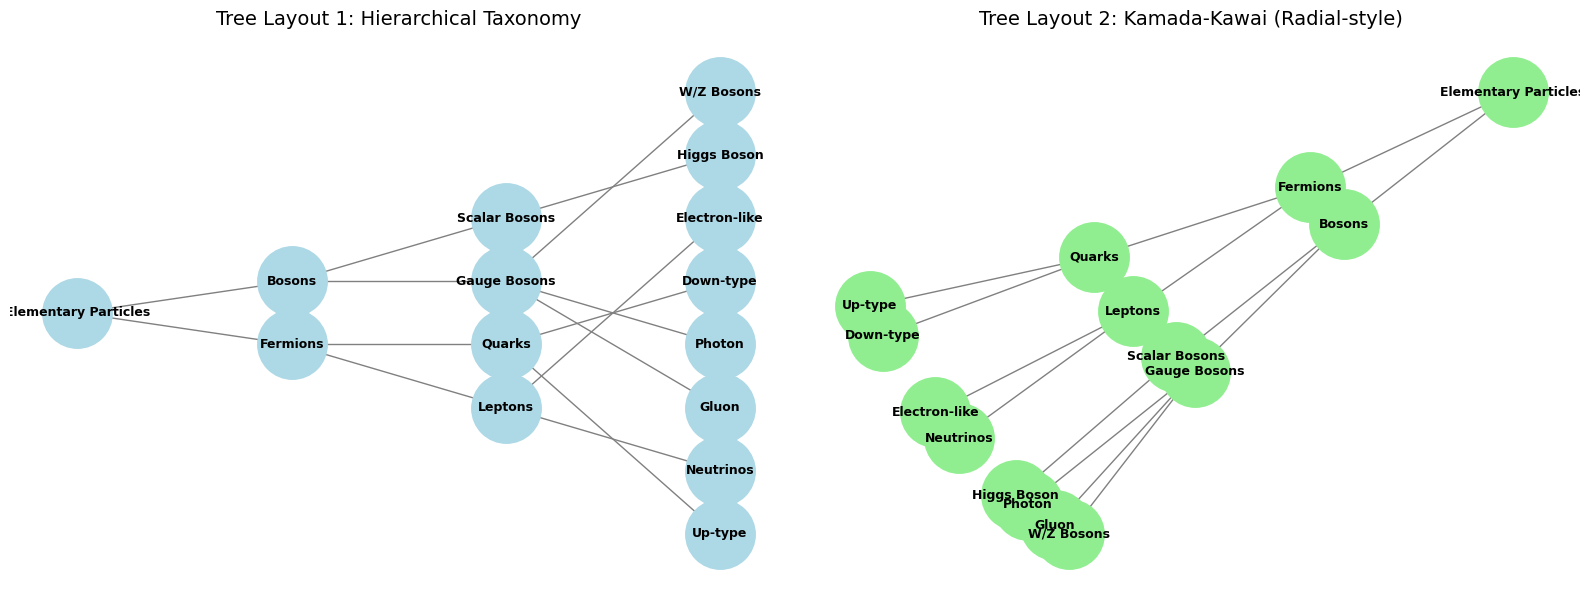

In [4]:
# Visualize the Tree Dataset utilizing at least two different layouts
plt.figure(figsize=(16, 6))

# --- Layout 1: Left-to-Right Hierarchical (Multipartite) Layout ---
plt.subplot(1, 2, 1)
# Uses the 'layer' attribute we assigned earlier to space nodes hierarchically
pos_hierarchical = nx.multipartite_layout(tree_data, subset_key="layer")
nx.draw(tree_data, pos_hierarchical,
        with_labels=True,
        node_color='lightblue',
        node_size=2500,
        edge_color='gray',
        font_size=9,
        font_weight='bold',
        arrows=False)
plt.title("Tree Layout 1: Hierarchical Taxonomy", fontsize=14, pad=15)

# --- Layout 2: Kamada-Kawai (Force-Directed/Radial) Layout ---
plt.subplot(1, 2, 2)
# Kamada-Kawai treats paths as springs, naturally pushing the root to the center
pos_radial = nx.kamada_kawai_layout(tree_data)
nx.draw(tree_data, pos_radial,
        with_labels=True,
        node_color='lightgreen',
        node_size=2500,
        edge_color='gray',
        font_size=9,
        font_weight='bold',
        arrows=False)
plt.title("Tree Layout 2: Kamada-Kawai (Radial-style)", fontsize=14, pad=15)

plt.tight_layout()
plt.show()

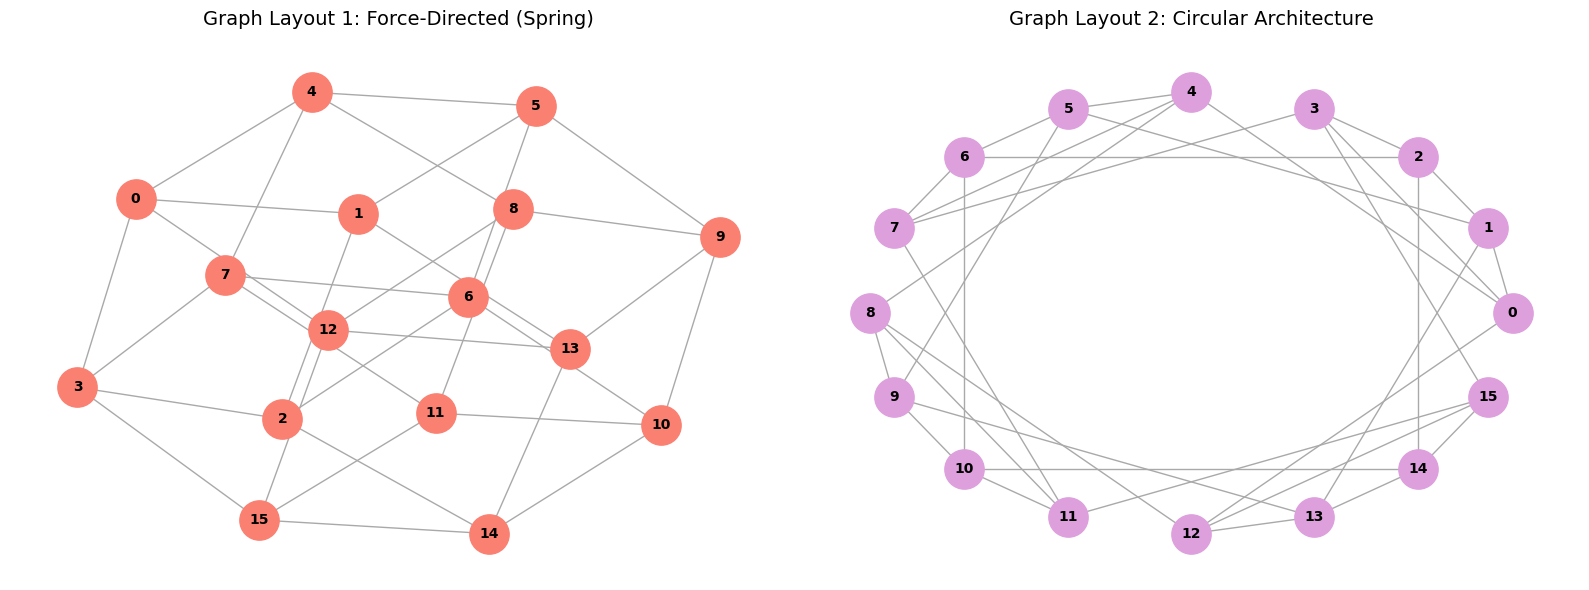

In [5]:
# Visualize the Graph dataset utilizing at least two different layouts
plt.figure(figsize=(16, 6))

# --- Layout 1: Spring (Force-directed) Layout
plt.subplot(1, 2, 1)
# Models edges as springs to show natural clustering and network tension
pos_spring = nx.spring_layout(graph_data, seed=42)
nx.draw(graph_data, pos_spring,
        with_labels=True,
        node_color='salmon',
        node_size=800,
        edge_color='darkgray',
        font_size=10,
        font_weight='bold')
plt.title("Graph Layout 1: Force-Directed (Spring)", fontsize=14, pad=15)

# --- Layout 2: Circular Layout ---
plt.subplot(1, 2, 2)
# Places all nodes on a circle, highly effective for highlighting edge routing/density
pos_circular = nx.circular_layout(graph_data)
nx.draw(graph_data, pos_circular,
        with_labels=True,
        node_color='plum',
        node_size=800,
        edge_color='darkgray',
        font_size=10,
        font_weight='bold')
plt.title("Graph Layout 2: Circular Architecture", fontsize=14, pad=15)

plt.tight_layout()
plt.show()